In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## A single run

In [2]:
#FOLDER = "04-03-26--14_34_00/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

# FOLDER = "26-02-26--11_04_41/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

# FOLDER = "05-03-26--14_56_45/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

FOLDER = "11-03-26--14_41_30/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
if FOLDER:
    data_dir = data_dir / FOLDER

run = load_run(data_dir)

# Normalize units: wei → ETH, ratio → %
run = normalize_run(run)
res = merge_runs([run])

### Aggregate global accuracy by round

In [3]:
# data = res['users']
# aggregated = agg_global_accuracy_by_round(data)
#
# aggregated

## Multiple runs

In [4]:
# FOLDER = "26-02-26--11_04_41/"
#
# data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
# if FOLDER:
#     data_dir = data_dir / FOLDER
#
# runs = load_runs(data_dir)
#
# # Normalize units: wei → ETH, ratio → %
# runs = normalize_runs(runs)
# res = merge_runs(runs)

## Plots

### Plot: plot_accuracy_loss_over_rounds

,experiment_id,round,round_time,objective_global_accuracy,objective_global_loss,reward_pool,punishment_pool,is_baseline
0,mnist-accuracy_only-3-1.0-3-1.0-True-False,0,0.000000,0.1341,720.399601,1.000000e+00,0.000000,True
1,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,115.482401,0.1135,718.657739,6.666667e-01,0.000000,False
2,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,91.465155,0.2814,701.912697,3.333333e-01,0.000000,False
3,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,80.481329,0.7146,299.360721,1.000000e-18,0.745089,False


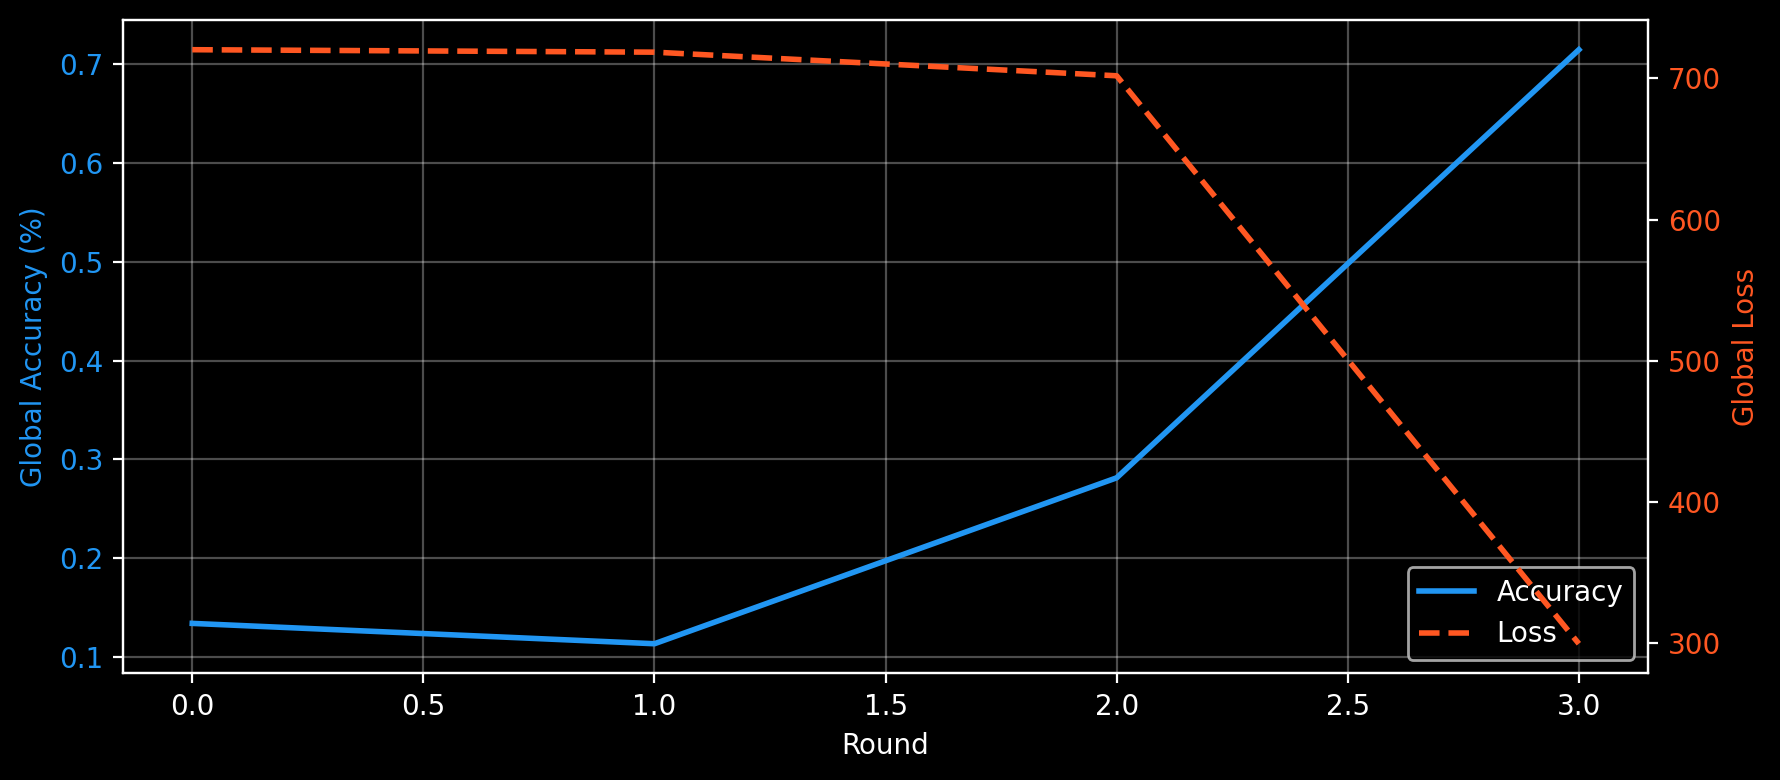

In [5]:
data = res['global']
aggregated = agg_global_accuracy_loss_by_round(data)

fig = plot_accuracy_loss_over_rounds(aggregated) # Assign since it otherwise will plot twice.
data
#

### Plot: plot_gas_cost_by_tx_type

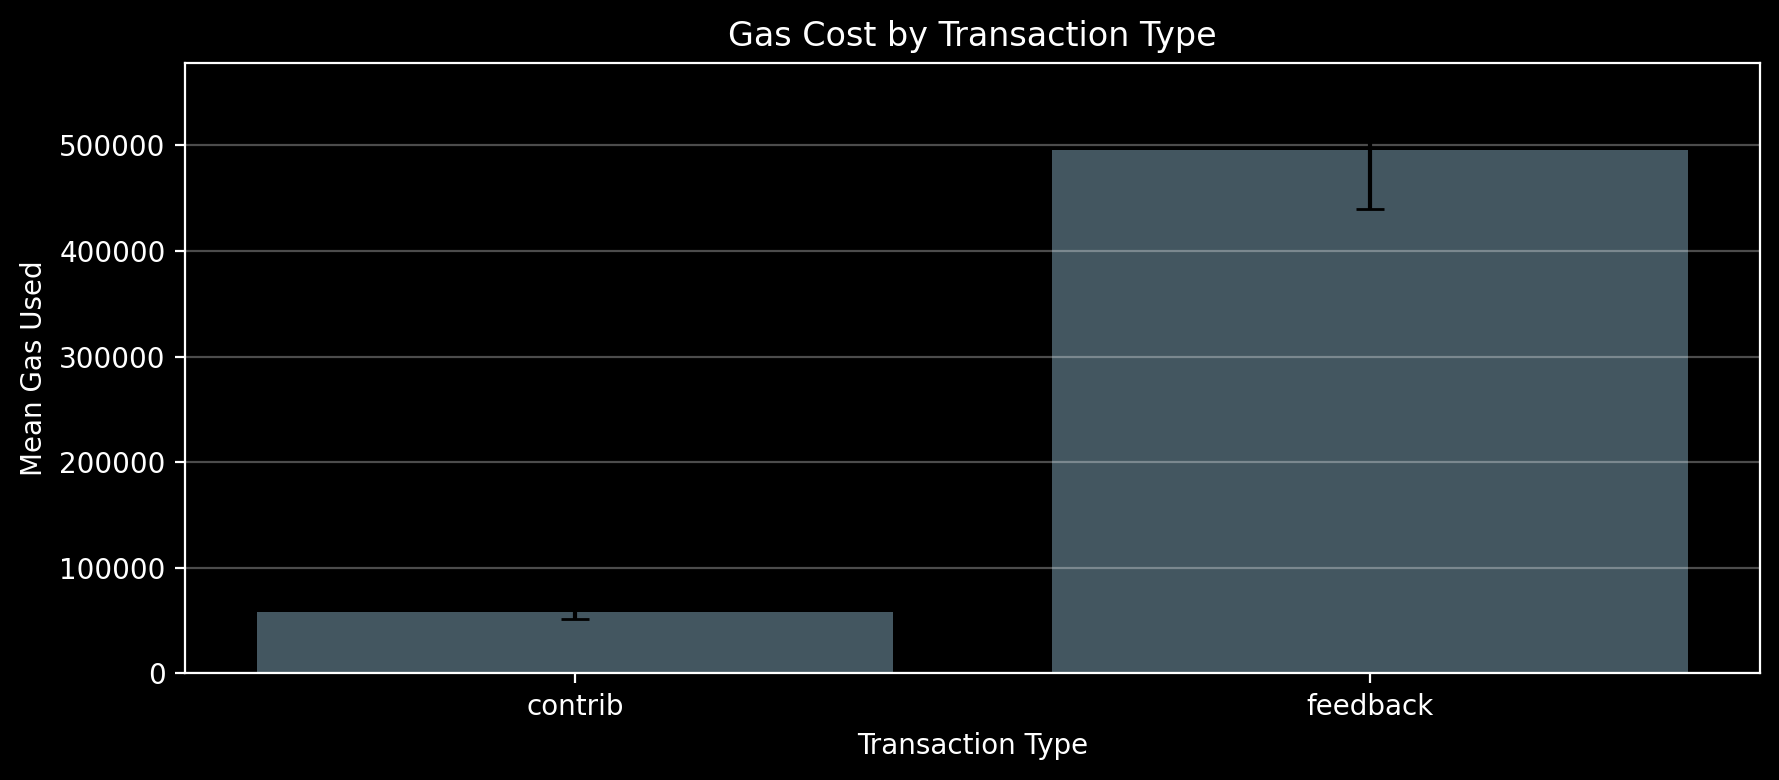

In [6]:
# plot_round_kicked_by_strategy(aggregated)
data = res['receipts']
aggregated = agg_gas_used_by_tx_type(data, res['metadata'])
fig = plot_gas_cost_by_tx_type(aggregated)

  ┌──────────────────────────────────────┬──────────────────────────────────┐
  │             Aggregation              │               Plot               │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_global_accuracy_by_round         │ plot_accuracy_loss_over_rounds   │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_accuracy_by_strategy             │ plot_strategy_comparison_lines   │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_final_round_accuracy_by_strategy │ plot_strategy_comparison_boxplot │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_grs_by_behavior                  │ plot_grs_by_behavior             │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_gas_used_by_tx_type              │ plot_gas_cost_by_tx_type         │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_round_kicked_by_strategy         │ plot_round_kicked_by_strategy    │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_contribution_score_by_behavior   │ (no corresponding plot)          │
  └──────────────────────────────────────┴──────────────────────────────────┘

### Plot: plot_round_kicked_by_strategy

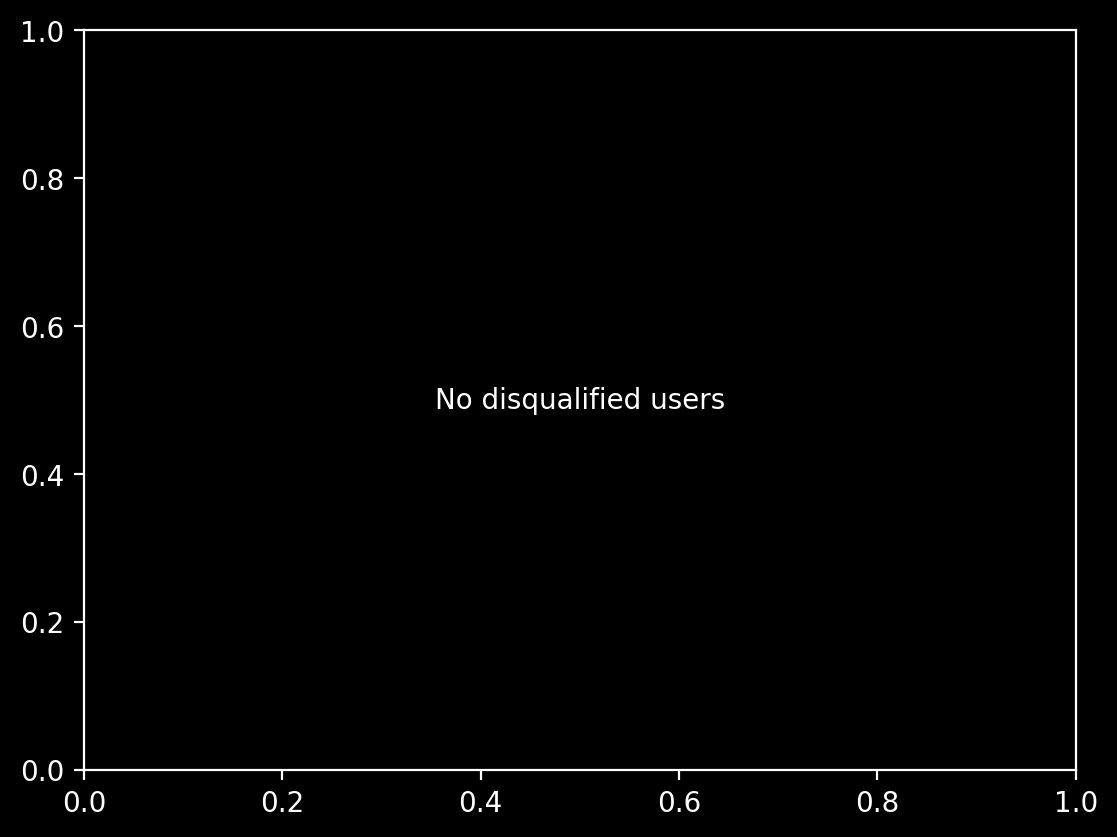

In [7]:
data = res['users']
aggregated = agg_round_kicked_by_strategy(data, res['metadata'])
fig = plot_round_kicked_by_strategy(aggregated)

## Plot: Agg. GRS by behavior

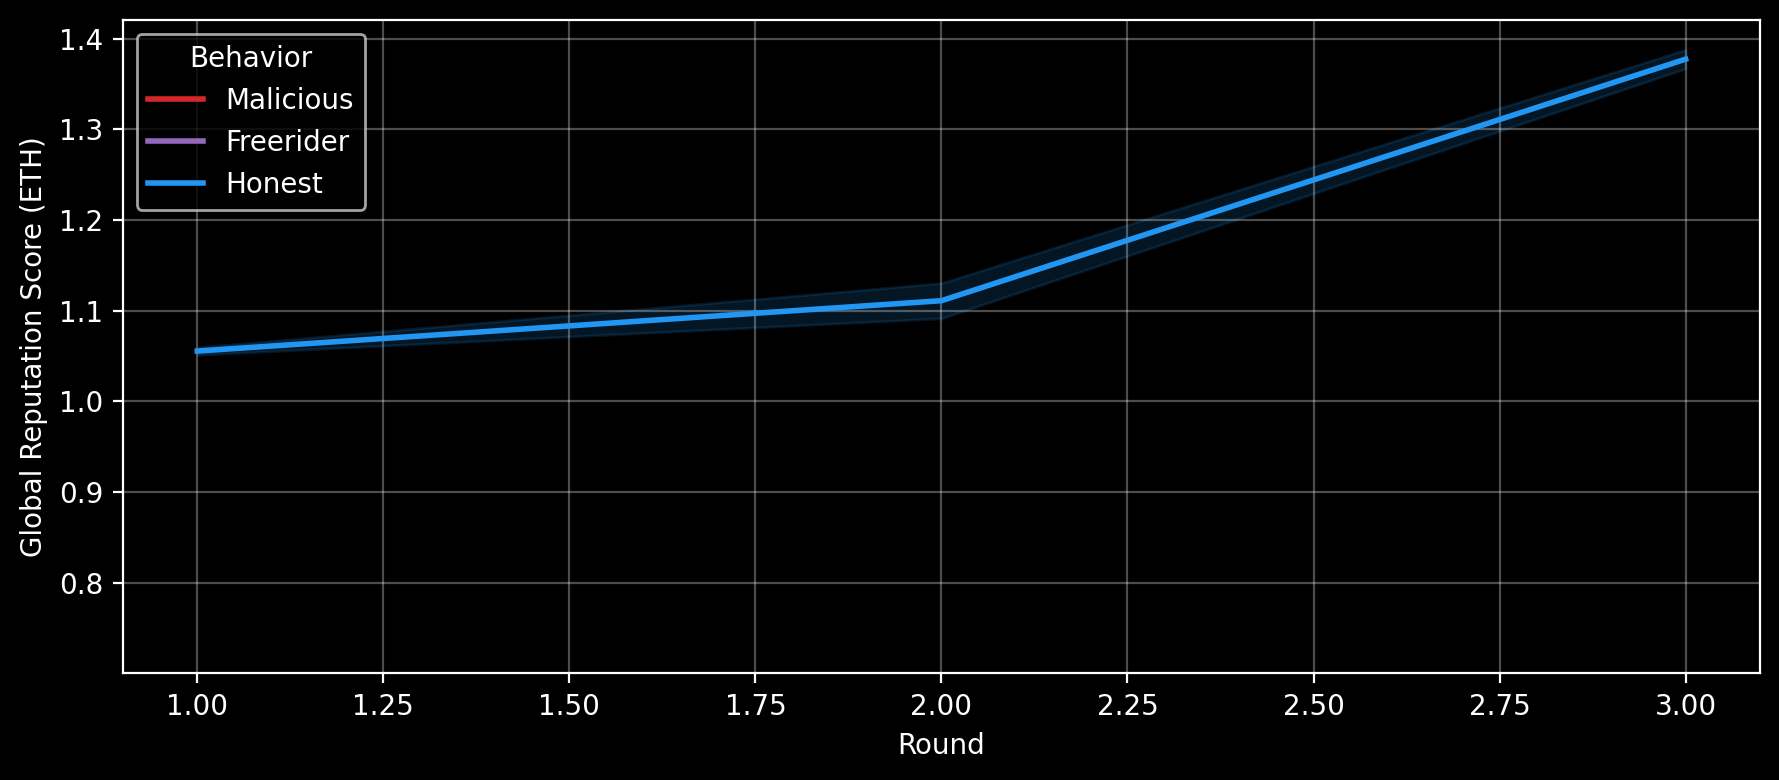

In [8]:
data = res['users']
aggregated = agg_grs_by_behavior(data)
fig = plot_grs_by_behavior(aggregated)


# Why are they not equal at round 3

## Plot: GRS by user

,experiment_id,round,user_id,state,behavior,role,grs,subjective_personal_accuracy,subjective_personal_loss,subjective_global_accuracy,subjective_global_loss,contribution_score,round_reputation_assigned,reward_delta,is_reward,merged
4,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,4,active,good,bad,1.050792,0.618,61.096930,"[0.633, 0.2336, 0.2814]","[596.3287292718887, 702.919355392456, 701.9126...",0.152376,2000000000000000000,0.050792,True,True
10,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,4,active,good,bad,1.099209,0.229,71.858793,"[0.633, 0.2336, 0.2814]","[596.3287292718887, 702.919355392456, 701.9126...",0.145252,5282541353101759364,0.048417,True,True
16,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,4,active,bad,bad,0.732806,0.229,71.858793,"[0.633, 0.2336, 0.2814]","[596.3287292718887, 702.919355392456, 701.9126...",0.145252,-4431399570401702953,NaN,None,False
5,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,5,active,good,freerider,1.060044,0.752,44.721907,"[0.7285, 0.3189, 0.2814]","[444.56129336357117, 702.1517889499664, 701.91...",0.180133,5000000000000000000,0.060044,True,True
11,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,5,active,good,freerider,1.136058,0.338,71.584970,"[0.7285, 0.3189, 0.2814]","[444.56129336357117, 702.1517889499664, 701.91...",0.228040,5273288953148762170,0.076013,True,True
17,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,5,active,freerider,freerider,0.757372,0.338,71.584970,"[0.7285, 0.3189, 0.2814]","[444.56129336357117, 702.1517889499664, 701.91...",0.228040,-5530608964754812456,NaN,None,False


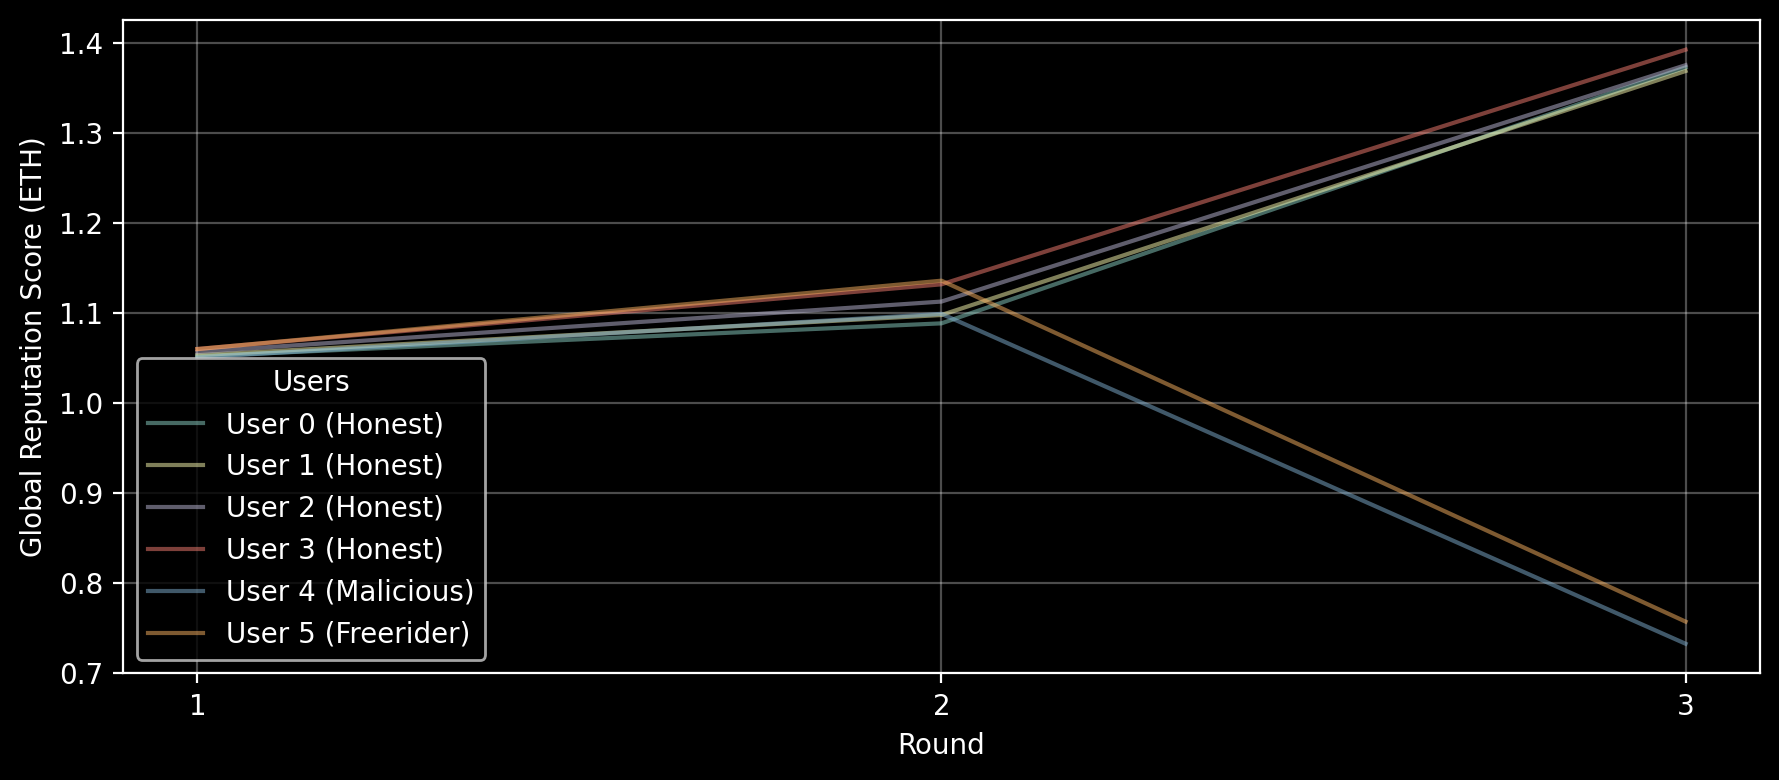

In [9]:
data = res['users']

# data[['grs', 'user_id', 'round']]

vals = grs_by_user(data)

fig = plot_grs_by_user(vals)

data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

In [10]:
data[data['behavior'] == 'good'].groupby('round')[['subjective_personal_accuracy', 'grs']].mean()

# data[data['behavior'] == 'good'] & (data['state'] == 'disqualified')

# data[(data['behavior'] == 'good') & (data['state'] == 'disqualified')]


,subjective_personal_accuracy,grs
round,,
1,0.6720,1.055556
2,0.2505,1.111111
3,0.6725,1.377455


In [11]:
data.sort_values('round')


# data = res['votes']
# data[['giver_id', 'giver_address']].drop_duplicates()

# data[data['user_id'] == 0]


data[data['round'] > 2].sort_values(['user_id', 'round'])

,experiment_id,round,user_id,state,behavior,role,grs,subjective_personal_accuracy,subjective_personal_loss,subjective_global_accuracy,subjective_global_loss,contribution_score,round_reputation_assigned,reward_delta,is_reward,merged
12,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,0,active,good,good,1.372962,0.685,33.024445,"[0.6247, 0.2078, 0.7108]","[635.8838384151459, 701.7242262363434, 313.781...",0.263634,2243536342286737278,0.284308,True,True
13,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,1,active,good,good,1.368889,0.664,32.310426,"[0.6691, 0.2225, 0.6841]","[540.1205693483353, 701.9159021377563, 308.823...",0.251281,2234287498054766351,0.270987,True,True
14,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,2,active,good,good,1.375391,0.688,32.615746,"[0.6984, 0.2467, 0.6958]","[534.5805308818817, 701.8994586467743, 315.059...",0.243447,2219337901017758454,0.262538,True,True
15,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,3,active,good,good,1.392580,0.653,33.182110,"[0.7208, 0.3023, 0.6678]","[407.065413415432, 701.539381980896, 309.05155...",0.241639,2200199392433408764,0.260589,True,True
16,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,4,active,bad,bad,0.732806,0.229,71.858793,"[0.633, 0.2336, 0.2814]","[596.3287292718887, 702.919355392456, 701.9126...",0.145252,-4431399570401702953,NaN,None,False
17,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,5,active,freerider,freerider,0.757372,0.338,71.584970,"[0.7285, 0.3189, 0.2814]","[444.56129336357117, 702.1517889499664, 701.91...",0.228040,-5530608964754812456,NaN,None,False
